#Mobile Legends: Bang Bang - Exploratory Data Analysis

**Author:** Biju

**Project:** Analyzing hero stats, roles, and meta trends in Mobile Legends

##Objectives
1. Understand the hero roster - roles, classes, lanes
2. Identify stat patterns across hero types
3. Find which heroes/roles are statistically strongest
4. Visualize key findings


In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded")

Libraries loaded


In [19]:
# Step 1: Install Kaggle and upload your API key
!pip install kaggle -q

from google.colab import files
print("Click 'Choose Files' below and upload your kaggle.json file:")
uploaded = files.upload()

Click 'Choose Files' below and upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [20]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API configured")

Kaggle API configured


In [21]:
!kaggle datasets download -d kishan9044/mobile-legends-bang-bang
!unzip -o mobile-legends-bang-bang.zip
!ls -la *.csv

Dataset URL: https://www.kaggle.com/datasets/kishan9044/mobile-legends-bang-bang
License(s): CC0-1.0
mobile-legends-bang-bang.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  mobile-legends-bang-bang.zip
  inflating: Mlbb_Heroes.csv         
-rw-r--r-- 1 root root 12824 Sep 24  2022 Mlbb_Heroes.csv


In [22]:
df = pd.read_csv("Mlbb_Heroes.csv")

print(f"Loaded {df.shape[0]} heroes with {df.shape[1]} columns\n")
print("Column names:")
print(df.columns.tolist())
print("\nFirst 5 heroes:")
df.head()

Loaded 114 heroes with 18 columns

Column names:
['Name', 'Title', 'Voice_Line', 'Release_Date', 'Primary_Role', 'Secondary_Role', 'Lane', 'Hp', 'Hp_Regen', 'Mana', 'Mana_Regen', 'Phy_Damage', 'Mag_Damage', 'Phy_Defence', 'Mag_Defence', 'Mov_Speed', 'Esport_Wins', 'Esport_Loss']

First 5 heroes:


,Name,Title,Voice_Line,Release_Date,Primary_Role,Secondary_Role,Lane,Hp,Hp_Regen,Mana,Mana_Regen,Phy_Damage,Mag_Damage,Phy_Defence,Mag_Defence,Mov_Speed,Esport_Wins,Esport_Loss
0,Aamon,Duke of Shards,"It is better to be feared than loved, if you c...",2021-10-25,Assassin,NaN,Jungler,2614,8.0,455,21.0,115,0,19,15,250,43,42
1,Akai,Panda Warrior,Now Akai enters the scene!,2016,Tank,Support,Roamer,2769,8.4,422,12.0,115,0,24,15,260,540,524
2,Aldous,Soul Contractor,Primary Role,2018,Fighter,NaN,EXP Lane,2718,9.8,405,18.0,129,0,21,15,260,95,92
3,Alice,Queen of Blood,Watch your back!,2016,Mage,Tank,EXP Lane,2573,7.2,493,18.0,114,0,21,15,240,364,352
4,Alpha,Blade of Enmity,Test! Alpha is online.,2017,Fighter,NaN,EXP Lane,2646,7.8,453,31.0,121,0,25,15,260,24,33


In [23]:
# See ALL 18 columns (the first view cut some off)
pd.set_option('display.max_columns', None)
df.head()

,Name,Title,Voice_Line,Release_Date,Primary_Role,Secondary_Role,Lane,Hp,Hp_Regen,Mana,Mana_Regen,Phy_Damage,Mag_Damage,Phy_Defence,Mag_Defence,Mov_Speed,Esport_Wins,Esport_Loss
0,Aamon,Duke of Shards,"It is better to be feared than loved, if you c...",2021-10-25,Assassin,NaN,Jungler,2614,8.0,455,21.0,115,0,19,15,250,43,42
1,Akai,Panda Warrior,Now Akai enters the scene!,2016,Tank,Support,Roamer,2769,8.4,422,12.0,115,0,24,15,260,540,524
2,Aldous,Soul Contractor,Primary Role,2018,Fighter,NaN,EXP Lane,2718,9.8,405,18.0,129,0,21,15,260,95,92
3,Alice,Queen of Blood,Watch your back!,2016,Mage,Tank,EXP Lane,2573,7.2,493,18.0,114,0,21,15,240,364,352
4,Alpha,Blade of Enmity,Test! Alpha is online.,2017,Fighter,NaN,EXP Lane,2646,7.8,453,31.0,121,0,25,15,260,24,33


In [24]:
# Get a summary of the dataset structure
print("=== Dataset Info ===\n")
df.info()

=== Dataset Info ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            114 non-null    object 
 1   Title           114 non-null    object 
 2   Voice_Line      114 non-null    object 
 3   Release_Date    114 non-null    object 
 4   Primary_Role    114 non-null    object 
 5   Secondary_Role  30 non-null     object 
 6   Lane            114 non-null    object 
 7   Hp              114 non-null    int64  
 8   Hp_Regen        114 non-null    float64
 9   Mana            114 non-null    int64  
 10  Mana_Regen      113 non-null    float64
 11  Phy_Damage      114 non-null    int64  
 12  Mag_Damage      114 non-null    int64  
 13  Phy_Defence     114 non-null    int64  
 14  Mag_Defence     114 non-null    int64  
 15  Mov_Speed       114 non-null    int64  
 16  Esport_Wins     114 non-null    int64  
 17  Esport_Loss  

In [25]:
# Count missing values per column
print("=== Missing values per column ===\n")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print(f"\nTotal heroes: {len(df)}")

=== Missing values per column ===

Secondary_Role    84
Mana_Regen         1
dtype: int64

Total heroes: 114


In [26]:
# Find the hero with missing Mana_Regen
missing_mana = df[df['Mana_Regen'].isnull()]
print("Hero(es) with missing Mana_Regen:")
print(missing_mana[['Name', 'Primary_Role', 'Mana', 'Mana_Regen']])

Hero(es) with missing Mana_Regen:
    Name Primary_Role  Mana  Mana_Regen
108  Yin      Fighter     0         NaN


In [27]:
#clean the data
df['Secondary_Role'] = df['Secondary_Role'].fillna('None')
df['Mana_Regen'] = df['Mana_Regen'].fillna(0)

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "missing values remaining")
print("\nSecondary_Role distribution:")
print(df['Secondary_Role'].value_counts())

Missing values after cleaning:
0 missing values remaining

Secondary_Role distribution:
Secondary_Role
None        84
Support      7
Tank         6
Assassin     6
Mage         5
Fighter      3
Marksman     3
Name: count, dtype: int64


/tmp/ipykernel_2429/1274521941.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_counts.index, y=role_counts.values, palette='viridis')


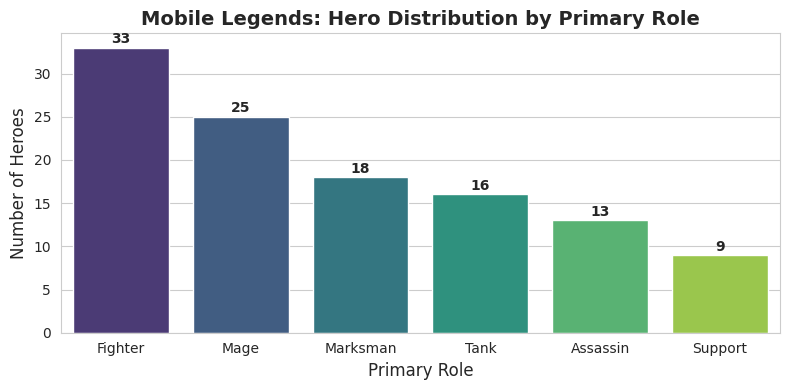


📊 Most common role: Fighter (33 heroes)


In [28]:
#vissualization
import matplotlib.pyplot as plt
import seaborn as sns

role_counts = df['Primary_Role'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=role_counts.index, y=role_counts.values, palette='viridis')

plt.title('Mobile Legends: Hero Distribution by Primary Role', fontsize=14, fontweight='bold')
plt.xlabel('Primary Role', fontsize=12)
plt.ylabel('Number of Heroes', fontsize=12)

for i, count in enumerate(role_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('hero_role_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Most common role: {role_counts.index[0]} ({role_counts.values[0]} heroes)")

In [29]:
# Group heroes by Primary_Role and calculate average stats
role_stats = df.groupby('Primary_Role')[['Hp', 'Mana', 'Phy_Damage',
                                          'Mag_Damage', 'Phy_Defence',
                                          'Mag_Defence', 'Mov_Speed']].mean()

# Round to 1 decimal place for cleaner output
role_stats = role_stats.round(1)

# Sort by HP (highest first) to see who's tankiest
role_stats = role_stats.sort_values('Hp', ascending=False)

print("📊 Average Combat Stats by Primary Role:\n")
role_stats

📊 Average Combat Stats by Primary Role:



,Hp,Mana,Phy_Damage,Mag_Damage,Phy_Defence,Mag_Defence,Mov_Speed
Primary_Role,,,,,,,
Tank,2722.2,301.2,120.9,0.0,19.1,14.7,255.5
Fighter,2635.3,179.7,118.5,0.0,22.1,15.0,256.8
Assassin,2559.9,339.2,116.9,0.0,18.0,15.0,256.5
Mage,2523.2,527.7,111.5,0.0,17.8,14.8,244.0
Marksman,2490.8,325.2,111.2,0.0,17.1,15.0,244.9
Support,2462.6,498.3,118.3,0.0,18.8,15.0,247.4


## Investigating the Mag_Damage Column

The grouped stats above showed `Mag_Damage = 0.0` for every role. This is suspicious because mages should clearly have magic damage.
Let's investigate whether this is a data quality issue or if it reflects how the game tracks damage values.

In [30]:
# Check the Mag_Damage column more carefully
print("Mag_Damage statistics across all heroes:")
print(df['Mag_Damage'].describe())

print("\nAny non-zero Mag_Damage values?")
print(df[df['Mag_Damage'] > 0][['Name', 'Primary_Role', 'Mag_Damage']])

Mag_Damage statistics across all heroes:
count    114.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Mag_Damage, dtype: float64

Any non-zero Mag_Damage values?
Empty DataFrame
Columns: [Name, Primary_Role, Mag_Damage]
Index: []


##Dropping the Mag_Damage Column

After investigating, the `Mag_Damage` column contains 0.0 for all 114 heroes,
a "dead column" with zero variance. In Mobile Legends, magic damage scales
from equipped items (Magic Power) rather than base hero stats, so this
dataset simply doesn't track it.

A column with no variance provides zero analytical value and would distort
correlation analysis. I'm dropping it.

In [31]:
# Drop the dead Mag_Damage column
df = df.drop('Mag_Damage', axis=1)

print(f"Mag_Damage dropped")
print(f"Dataset now has {df.shape[1]} columns (was 18, now {df.shape[1]})")
print("\nRemaining numeric columns:")
print(df.select_dtypes(include='number').columns.tolist())

Mag_Damage dropped
Dataset now has 17 columns (was 18, now 17)

Remaining numeric columns:
['Hp', 'Hp_Regen', 'Mana', 'Mana_Regen', 'Phy_Damage', 'Phy_Defence', 'Mag_Defence', 'Mov_Speed', 'Esport_Wins', 'Esport_Loss']


##HP Distribution by Role - Statistical View

The previous bar chart showed *average* HP per role, but averages hide variation.
A boxplot reveals the full distribution: median (middle line), the middle 50%
of heroes (the box), and any outliers (dots beyond the whiskers).

This will help answer: Are roles internally consistent in HP, or do some
roles have huge variation? Are there any "outlier" heroes that defy their
role's typical pattern?

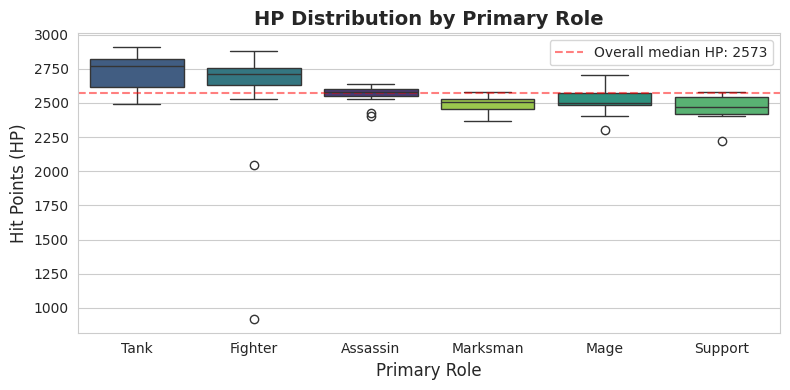


 Chart saved! Overall HP median across all heroes: 2573


In [34]:
# Create a boxplot of HP across primary roles
plt.figure(figsize=(8, 4))

# Order roles by median HP (highest to lowest)
role_order = df.groupby('Primary_Role')['Hp'].median().sort_values(ascending=False).index

# Build the boxplot
sns.boxplot(data=df, x='Primary_Role', y='Hp', order=role_order,
            hue='Primary_Role', palette='viridis', legend=False)

# Styling
plt.title('HP Distribution by Primary Role', fontsize=14, fontweight='bold')
plt.xlabel('Primary Role', fontsize=12)
plt.ylabel('Hit Points (HP)', fontsize=12)

# Add a horizontal line showing the overall median for context
overall_median_hp = df['Hp'].median()
plt.axhline(overall_median_hp, color='red', linestyle='--', alpha=0.5,
            label=f'Overall median HP: {overall_median_hp:.0f}')
plt.legend()

plt.tight_layout()
plt.savefig('hp_distribution_by_role.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Chart saved! Overall HP median across all heroes: {overall_median_hp:.0f}")

## Findings

The boxplot reveals a striking outlier: a Fighter with HP around 900 was far below any other Fighter and even below the lowest Marksman. This is worth investigating because outliers often signal either unique game mechanics or potential data quality issues.

In [35]:
# Find unusual HP values - heroes with HP far from their role's typical
print("=== Lowest-HP heroes in the dataset ===\n")
print(df.nsmallest(5, 'Hp')[['Name', 'Primary_Role', 'Secondary_Role', 'Hp', 'Phy_Damage']])

print("\n=== Highest-HP heroes in the dataset ===\n")
print(df.nlargest(5, 'Hp')[['Name', 'Primary_Role', 'Secondary_Role', 'Hp', 'Phy_Damage']])

=== Lowest-HP heroes in the dataset ===

        Name Primary_Role Secondary_Role    Hp  Phy_Damage
107   X.Borg      Fighter           None   918         117
79     Masha      Fighter           Tank  2043          91
32     Estes      Support           None  2221         120
23   Chang'e         Mage           None  2301         115
25    Claude     Marksman           None  2370          97

=== Highest-HP heroes in the dataset ===

        Name Primary_Role Secondary_Role    Hp  Phy_Damage
54     Hylos         Tank           None  2909         105
58    Julian      Fighter           Mage  2878         128
97  Silvanna      Fighter           None  2868         126
81  Minotaur         Tank        Support  2859         123
90   Phoveus      Fighter           None  2828         132


### Conclusion

X.Borg's low base HP is intentional game design, his survivability comes from a **Flame Armor** mechanic that acts as a second health bar. The dataset captures base stats only, not mechanic-driven survivability.

Similarly, Masha (2043 HP) has *three* health bars in-game, but the data
shows only her first. These outliers are not data errors, they reflect
hero-specific mechanics that the base stats don't capture.

**Takeaway:** Always investigate outliers before dismissing them. Domain
knowledge transforms suspicious data points into meaningful insights.

## Correlation Heatmap - How Are Hero Stats Related?

So far I looked at one variable at a time (HP by role, etc.).
A **correlation heatmap** help to see relationships across all numeric
stats simultaneously revealing patterns in hero design.

### Questions to answer:

1. **Trade-offs:** Do high-HP heroes tend to have lower movement speed?
   Do high-damage heroes have lower defense?
2. **Clusters:** Are some stats tightly linked (e.g., do Phy_Defence and
   Mag_Defence move together)?
3. **Esports performance:** Do any base stats correlate with competitive
   wins or losses?

### How to read a correlation value:

- **+1.0** = perfect positive correlation (when one goes up, the other goes up)
- **0.0** = no relationship
- **-1.0** = perfect negative correlation (when one goes up, the other goes down)

Values between **0.3–0.7** (or -0.3 to -0.7) are considered meaningful patterns
worth investigating.

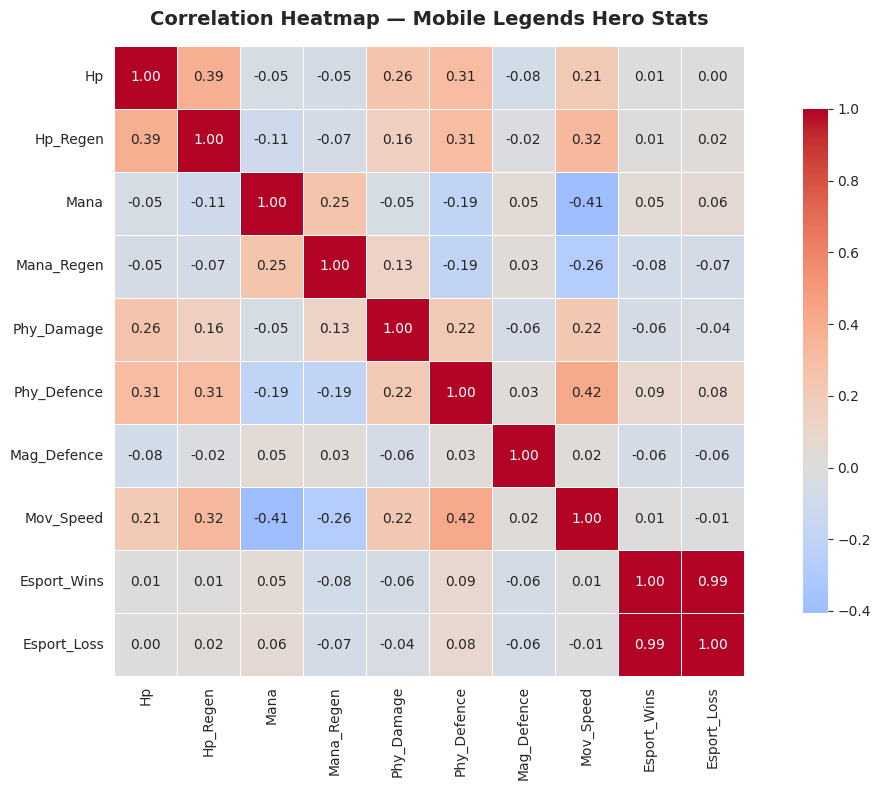


 Heatmap saved! Strongest correlations to watch:

Top 3 positive:
Esport_Wins  Esport_Loss    0.989907
Phy_Defence  Mov_Speed      0.418756
Hp           Hp_Regen       0.385867
dtype: float64

Top 3 negative:
Phy_Defence  Mana         -0.192372
Mov_Speed    Mana_Regen   -0.263852
Mana         Mov_Speed    -0.405940
dtype: float64


In [38]:
# Select only numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include='number').columns.tolist()
correlation_matrix = df[numeric_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix,
            annot=True,           # Show numbers in each cell
            fmt='.2f',            # Format numbers to 2 decimal places
            cmap='coolwarm',      # Red = positive, Blue = negative
            center=0,             # Center colormap at 0 (no correlation)
            square=True,          # Make cells square-shaped
            linewidths=0.5,       # Lines between cells
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap — Mobile Legends Hero Stats',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Heatmap saved! Strongest correlations to watch:")
# Get the strongest correlations (excluding 1.0 self-correlations)
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlations
print("\nTop 3 positive:")
print(corr_pairs.head(6)[::2])  # Every other (since pairs appear twice)
print("\nTop 3 negative:")
print(corr_pairs.tail(6)[::2])

### Observations from the Heatmap

**Strong positive correlations:**
- `Phy_Defence to Mov_Speed` (0.42) - Tanky heroes are surprisingly mobile,
  reflecting role-clustering: tanks pair defense with utility-grade movement.
- `Hp to Phy_Defence` (0.31) - Heroes built to absorb damage get the full
  durability package.

**Strong negative correlations (trade-offs):**
- `Mana to Mov_Speed` (-0.41) - Mana-using spell casters trade mobility
  for spell power. This is the clearest design trade-off in MLBB.

**Independent stat:**
- `Mag_Defence` shows near-zero correlation with everything (|r| < 0.10),
  suggesting it's an independent balancing lever.

** Critical finding - Esport_Wins & Esport_Loss (0.99):**
The unusually high correlation between wins and losses suggests both
metrics reflect **pick frequency**, not competitive performance. A hero
picked 400 times with 200 wins and 200 losses looks "successful" in raw
counts, but has only a 50% win rate.

To analyze true competitive strength, we need to engineer a normalized
**Win Rate** feature: `Wins / (Wins + Losses)`.

## Feature Engineering - Calculating True Win Rate

The correlation analysis revealed that raw `Esport_Wins` and `Esport_Loss`
counts reflect **pick frequency**, not hero strength. To find heroes that
actually win when picked, we need to engineer new features:

1. **`Total_Matches`** = `Esport_Wins + Esport_Loss` - total times picked
2. **`Win_Rate`** = `Esport_Wins / Total_Matches` - true win percentage

### Statistical significance — why we need to filter

A hero picked once with one win has a 100% win rate but is statistically
meaningless. Just like flipping a coin once and seeing "heads" doesn't
prove a 100% heads probability. We need enough matches to trust the rate.

**Rule of thumb:** Require at least 30 matches for a hero's win rate to
be statistically meaningful.

In [39]:
# Engineer two new features
df['Total_Matches'] = df['Esport_Wins'] + df['Esport_Loss']
df['Win_Rate'] = (df['Esport_Wins'] / df['Total_Matches']).round(3)

# Some heroes might have 0 total matches (never picked in pro play)
# That would cause division by zero → NaN. Let's check.
print("Heroes never picked in pro play:")
never_picked = df[df['Total_Matches'] == 0]
print(f"Count: {len(never_picked)}")
if len(never_picked) > 0:
    print(never_picked[['Name', 'Primary_Role', 'Esport_Wins', 'Esport_Loss']])

print("\n=== Match Count Distribution ===")
print(df['Total_Matches'].describe().round(1))

print("\n=== Sample of new features ===")
print(df[['Name', 'Primary_Role', 'Esport_Wins', 'Esport_Loss',
          'Total_Matches', 'Win_Rate']].head(10))

Heroes never picked in pro play:
Count: 0

=== Match Count Distribution ===
count     114.0
mean      579.6
std       547.1
min         3.0
25%       142.8
50%       450.5
75%       936.8
max      2886.0
Name: Total_Matches, dtype: float64

=== Sample of new features ===
      Name Primary_Role  Esport_Wins  Esport_Loss  Total_Matches  Win_Rate
0    Aamon     Assassin           43           42             85     0.506
1     Akai         Tank          540          524           1064     0.508
2   Aldous      Fighter           95           92            187     0.508
3    Alice         Mage          364          352            716     0.508
4    Alpha      Fighter           24           33             57     0.421
5  Alucard      Fighter           22           33             55     0.400
6   Angela      Support          253          325            578     0.438
7    Argus      Fighter            2            7              9     0.222
8    Atlas         Tank          277          254    

### Filtering for Statistical Significance

The match counts vary enormously (3 to 2,886), which is a problem.
Heroes with only a handful of matches have unreliable win rates are
extreme values like 22.2% (Argus, 9 matches) or 100% wouldn't be
meaningful indicators.

To draw reliable conclusions, we'll filter to heroes with at least
**100 matches** this is enough to dampen luck-based fluctuations while
keeping a healthy sample size.

In [40]:
# Filter to heroes with statistically meaningful match counts
THRESHOLD = 100
df_significant = df[df['Total_Matches'] >= THRESHOLD].copy()

print(f"Heroes with ≥{THRESHOLD} matches: {len(df_significant)} out of {len(df)}")
print(f"Heroes filtered out: {len(df) - len(df_significant)}\n")

# Show the top 10 win-rate heroes (statistically significant)
print(f"=== Top 10 Win-Rate Heroes (≥{THRESHOLD} matches) ===\n")
top_winners = df_significant.nlargest(10, 'Win_Rate')[
    ['Name', 'Primary_Role', 'Total_Matches', 'Win_Rate']
]
print(top_winners.to_string(index=False))

print(f"\n=== Bottom 10 Win-Rate Heroes (≥{THRESHOLD} matches) ===\n")
bottom_losers = df_significant.nsmallest(10, 'Win_Rate')[
    ['Name', 'Primary_Role', 'Total_Matches', 'Win_Rate']
]
print(bottom_losers.to_string(index=False))

Heroes with ≥100 matches: 89 out of 114
Heroes filtered out: 25

=== Top 10 Win-Rate Heroes (≥100 matches) ===

       Name Primary_Role  Total_Matches  Win_Rate
    Faramis      Support            280     0.579
     Franco         Tank            627     0.574
     Kadita         Mage            346     0.572
     Wanwan     Marksman            725     0.570
     Eudora         Mage            145     0.538
     Lolita      Support            944     0.538
      Masha      Fighter            599     0.536
Yi_Sun-Shin     Assassin            826     0.536
        Yve         Mage           1556     0.536
    Dyrroth      Fighter            645     0.535

=== Bottom 10 Win-Rate Heroes (≥100 matches) ===

    Name Primary_Role  Total_Matches  Win_Rate
 Leomord      Fighter            211     0.422
 Cyclops         Mage            159     0.434
 Chang'e         Mage            506     0.437
  Angela      Support            578     0.438
Cecilion         Mage           1058     0.444
Beler

## Which Roles Dominate Pro Play?

Looking at individual top/bottom heroes is interesting, but as an analyst
I want to see the **bigger picture**: which roles, on average, win more
in pro play?

A boxplot will show both the median win rate per role AND the variance -
revealing whether a role is consistently strong, consistently weak, or
mixed.

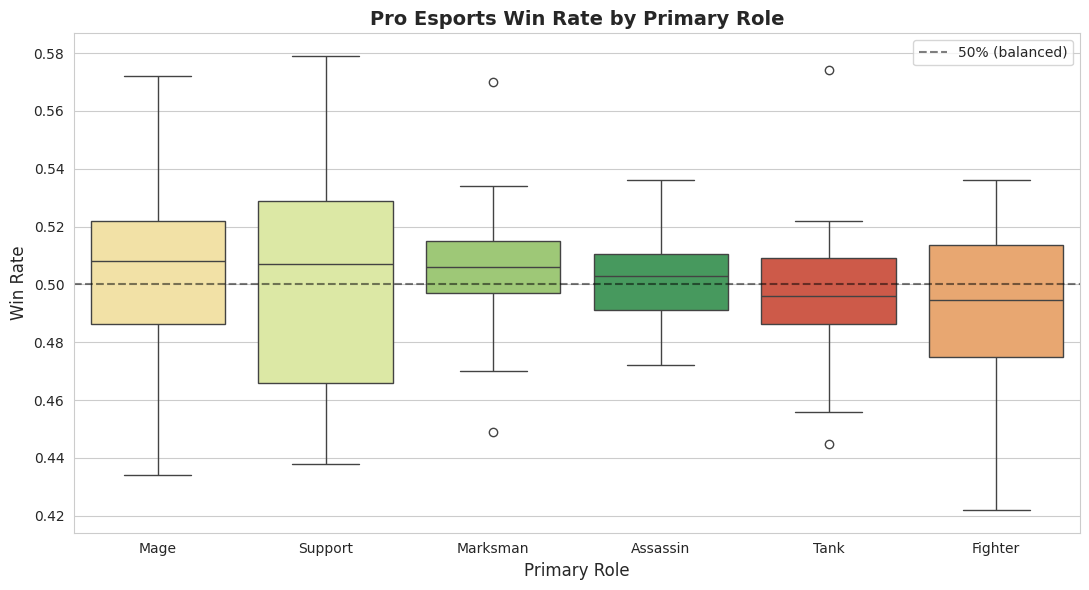


📊 Median Win Rate by Role:
Primary_Role
Mage        0.508
Support     0.507
Marksman    0.506
Assassin    0.503
Tank        0.496
Fighter     0.494
Name: Win_Rate, dtype: float64


In [41]:
# Boxplot of Win_Rate by Primary_Role (statistically significant heroes only)
plt.figure(figsize=(11, 6))

# Order roles by median win rate (highest first)
role_order = df_significant.groupby('Primary_Role')['Win_Rate'].median().sort_values(ascending=False).index

sns.boxplot(data=df_significant, x='Primary_Role', y='Win_Rate',
            order=role_order, hue='Primary_Role', palette='RdYlGn', legend=False)

# Reference line at 50% (the "balanced" win rate)
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5,
            label='50% (balanced)')

plt.title('Pro Esports Win Rate by Primary Role', fontsize=14, fontweight='bold')
plt.xlabel('Primary Role', fontsize=12)
plt.ylabel('Win Rate', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('winrate_by_role.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the median win rate per role
print("\n📊 Median Win Rate by Role:")
median_wr = df_significant.groupby('Primary_Role')['Win_Rate'].median().sort_values(ascending=False).round(3)
print(median_wr)

### Key Findings from Win Rate by Role Analysis

**Headline:** Mobile Legends shows exceptional class balance - median
win rates across all 6 roles cluster within just **1.4 percentage points**
(49.4% – 50.8%). At the pro level, role choice barely matters; hero
choice and player skill drive outcomes.

**Variance tells a deeper story:**
- **Mage and Support** show the widest variance - hero choice within
  these roles is critical. The top performer (Faramis, Support, 57.9%)
  and several bottom performers (Angela, Cyclops, Cecilion) all come
  from these classes.
- **Marksman and Assassin** show tight clustering - hero choice within
  these roles matters less; they're remarkably consistent.
- **Fighter** has a slightly lower median (49.4%) but the widest spread,
  including the dataset's worst performer (Leomord, 42.2%).

**Original hypothesis revisited:** "Rare roles (Support) might compensate
with higher win rates" - partially confirmed. Support has the 2nd highest
median AND the #1 individual hero, but also high variance - picking the
right Support is critical.